# Add the Rybizki fidelity dataset

This notebook downloads the Rybizki Gaia fidelity catalog, unpacks the per-level `.npy` files, and turns the fidelity values into a Dask DataFrame keyed by `source_id`.

The main practical goal is to prepare a table with two columns:

- `source_id`: the Gaia source identifier, stored as `int64`.
- `fidelity_v2`: the fidelity value, stored as `float32` to keep memory use down.

Later cells use a Dask distributed client named `c`. You can create one with `c = Client()` for a local cluster, or connect to a shared scheduler before scattering the partitions (see the example cell below).

In [1]:
import numpy as np

## Download the catalog archive

The source archive is downloaded directly into the working directory as `fidelities.zip`. Run this from a machine or notebook environment with enough local disk space for both the zip file and the extracted `fidelities/` directory.

In [2]:
#! wget "https://keeper.mpdl.mpg.de/d/21d3582c0df94e19921d/files/?p=%2Fwhole_catalog_v2%2Ffidelities.zip&dl=1" -O fidelities.zip


In [3]:
#! python3 -c "import zipfile; zipfile.ZipFile('fidelities.zip').extractall('.')"

## Inspect one file

Before building a distributed table, inspect a representative `.npy` file to confirm the available fields and dtypes. The notebook expects each file to contain `source_id` and `fidelity_v2`.

In [4]:
# inspect the data
arr = np.load('fidelities/lvl5_12205.npy')
print(arr.dtype.names)
# ('source_id', 'fidelity_v2')

('source_id', 'fidelity_v2')


## Build coarse partitions locally

The fidelity catalog is split across many small `.npy` files. Submitting every file as its own Dask task would create a very large task graph and spend too much time in scheduler overhead. This cell groups the files into a smaller number of pandas DataFrames first, then uses those DataFrames as the eventual Dask partitions.

The casts are intentional: `source_id` becomes a stable integer key, while `fidelity_v2` is kept as `float32` to reduce the amount of data scattered to workers.

In [5]:
import glob
import numpy as np
import pandas as pd
import dask.dataframe as dd
from dask import delayed
import time

# Grab all files
files = sorted(glob.glob('fidelities/lvl5_*.npy'))


def load_one(fpath):
    arr = np.load(fpath)
    return pd.DataFrame({
        'source_id': arr['source_id'].astype('int64'),
        'fidelity_v2': arr['fidelity_v2'].astype('float32'),
    })

# Batch files into ~200 chunks rather than scattering 12,000 tiny pieces —
# reduces scheduler overhead significantly
n_chunks = 200
chunks = np.array_split(files, n_chunks)

_t1 = time.time()

partitions = []
for chunk_files in chunks:
    dfs = [load_one(f) for f in chunk_files]
    partitions.append(pd.concat(dfs, ignore_index=True))

print('Time elapsed: ',time.time()-_t1)



Time elapsed:  174.65937900543213


## Scatter partitions to workers

This step sends the prepared pandas partitions to the connected Dask cluster. It uses small batches so the client does not try to push every partition at once. 

In [6]:
from dask.distributed import Client

# this is specific to AstroFlow's Dask Operator, which is running in the same Kubernetes cluster as this notebook
c = Client('tcp://simple-scheduler.dask-operator.svc.cluster.local:8786')
print(c)

<Client: 'tcp://172.19.205.19:8786' processes=10 threads=50, memory=700.00 GiB>


/opt/conda/lib/python3.12/site-packages/distributed/client.py:1590: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| numpy   | 2.0.2  | 2.2.6     | 2.2.6   |
| toolz   | 1.0.0  | 0.12.0    | 0.12.0  |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


In [7]:
futures = []
batch_size = 10  # scatter a handful at a time, not all 200 at once
for i in range(0, len(partitions), batch_size):
    batch = partitions[i:i+batch_size]
    futures.extend(c.scatter(batch))

## Wrap futures as a Dask DataFrame

Each scattered pandas DataFrame is represented by a future. Wrapping the futures with `delayed` lets `dd.from_delayed` assemble them into one logical Dask DataFrame. Supplying `meta` gives Dask the schema up front, so it does not need to execute a sample task just to infer column names and dtypes.

In [8]:
import dask.dataframe as dd
from dask import delayed

# Wrap each future as a delayed object so dask.dataframe knows how to treat it
delayed_dfs = [delayed(f) for f in futures]

# Need meta - the empty-frame schema - to avoid dask inspecting data itself
meta = partitions[0].iloc[:0]  # empty DataFrame with correct columns/dtypes

ddf = dd.from_delayed(delayed_dfs, meta=meta)

print(ddf.npartitions)  # should match len(futures)
print(ddf.dtypes)

200
source_id        int64
fidelity_v2    float32
dtype: object


## Index by Gaia source id

Setting `source_id` as the index makes later joins and lookups by Gaia source id more natural. This is also the expensive distributed step: Dask has to shuffle rows between partitions so that the index ordering and partition divisions are consistent.

In [9]:
from dask.distributed import wait
_t1 = time.time()

ddf = ddf.set_index('source_id').persist()  # triggers shuffle
wait(ddf)

print('Time elapsed: ',time.time()-_t1)


Time elapsed:  0.0015861988067626953


## Preview the result

`head()` pulls a small sample back to the notebook process. At this point, check that the index is `source_id`, the `fidelity_v2` column is present, and the values look plausible before writing the dataset out or joining it with other Gaia tables.

In [10]:
ddf.head()

,fidelity_v2
source_id,
4295806720,0.999512
34361129088,1.000000
38655544960,1.000000
309238066432,0.984863
343597448960,1.000000


## Cross-match against Gaia RVS

The next cells join the fidelity table to a filtered subset of Gaia DR3 sources with radial velocities. This gives a working sample with usable astrometry, an available `radial_velocity`, and the Rybizki `fidelity_v2` value attached by `source_id`.

The Gaia source data is read from parquet using `DASK_DATA_PATH_GAIA_DR3_SSD`, so that environment variable needs to point at the local or mounted Gaia DR3 data root.

In [11]:
from pathlib import Path
import os

source_cols = ['source_id',
              'phot_g_mean_mag',
              'ruwe',
              'radial_velocity','parallax_over_error']

data_root = os.environ.get('DASK_DATA_PATH_GAIA_DR3_SSD')
if not data_root:
    raise ValueError('DASK_DATA_PATH_GAIA_DR3_SSD is not set; point it at the Gaia DR3 data root')

gaia_source = dd.read_parquet(Path(data_root).joinpath('GDR3_GAIA_SOURCE/'), 
                           columns=source_cols)


gaia_source = gaia_source[
    gaia_source["radial_velocity"].notnull()
].persist()

## Attach fidelity values

Only the columns needed for the cross-match and quality checks are loaded from Gaia. The filters are persisted in two stages to keep the working set smaller before the join. The inner merge keeps sources that appear in both the filtered Gaia RVS sample and the fidelity catalog.

In [12]:
# set up to do the merge
result = gaia_source.merge(ddf, on="source_id", how="inner")

## Materialize the matched sample

The merge is still lazy until `compute()` runs. This brings the matched subset back into the notebook process as a pandas DataFrame, so it is best done after the Gaia filters have made the result small enough to fit in memory.

In [13]:
_t1 = time.time()

smalldf = result.compute()

print('Time elapsed: ',time.time()-_t1)

# this has been chopped down a bit already, but let's just see how much time it takes
# took 101s to do the merge, but without the partition mapping will probably take longer

Time elapsed:  115.06316208839417


## Preview the cross-match

A quick `head()` check should show Gaia columns plus the joined `fidelity_v2` value. This is a lightweight sanity check before summarizing the fidelity distribution.

In [14]:
smalldf.head()

,source_id,phot_g_mean_mag,ruwe,radial_velocity,parallax_over_error,fidelity_v2
0,151653959489092864,13.447948,0.977218,-15.531165,72.541687,1.0
1,199314043342207872,12.888233,0.985297,-3.900403,41.057331,1.0
2,205228724408179840,14.551772,0.989370,-41.769413,38.590706,1.0
3,251341524820645120,14.796630,1.048364,-9.391653,38.514118,1.0
4,284754824193385728,14.692492,1.011302,36.201477,30.171864,1.0


## Locate the 0.5 fidelity threshold

To understand how strict a `fidelity_v2 = 0.5` threshold is for this matched sample, compute the empirical percentile rank of 0.5 among finite fidelity values. This reports the percentile closest to the threshold rather than guessing a fixed percentile by hand.

In [15]:
target_fidelity = 0.5
fidelity = smalldf['fidelity_v2'].to_numpy()
finite_fidelity = fidelity[np.isfinite(fidelity)]
if len(finite_fidelity) == 0:
    raise ValueError('No finite fidelity_v2 values found in smalldf')

sorted_fidelity = np.sort(finite_fidelity)
percentile_at_target = 100.0 * np.searchsorted(
    sorted_fidelity,
    target_fidelity,
    side='right',
) / len(sorted_fidelity)
nearest_percentile_value = np.nanpercentile(
    finite_fidelity,
    percentile_at_target,
)

print(f'fidelity_v2 = {target_fidelity} is closest to the {percentile_at_target:.3f}th percentile')
print(f'np.nanpercentile(..., {percentile_at_target:.3f}) = {nearest_percentile_value:.6f}')

fidelity_v2 = 0.5 is closest to the 4.172th percentile
np.nanpercentile(..., 4.172) = 0.500468


In this matched sample, a `fidelity_v2 = 0.5` threshold lands around the ~4th percentile of finite fidelity values (the exact value depends on the filters above).

In [16]:
from pathlib import Path
Path('data').mkdir(parents=True, exist_ok=True)
smalldf.to_parquet('data/rvs_joined_rybizki.parquet', engine='pyarrow', compression='zstd')

In [17]:
import pandas as pd
smalldf = pd.read_parquet('data/rvs_joined_rybizki.parquet', engine='pyarrow')

Some sources may have high RUWE while still showing high `fidelity_v2`; a useful follow-up is to inspect these subsets and compare the underlying quality flags and astrometric fields.

In [18]:
import easy2dhist
import matplotlib.cm as cm
import matplotlib.pyplot as plt


In [19]:
badruwe = smalldf[smalldf['ruwe']>3.0]
goodfidelity_badruwe = badruwe[badruwe['fidelity_v2']>0.99]
print('There are',goodfidelity_badruwe.shape[0],'sources with extremely high ruwe, but high fidelity measurements.')

There are 686096 sources with extremely high ruwe, but high fidelity measurements.


/home/jovyan/easy2dhist.py:57: RuntimeWarning: invalid value encountered in cast
  ix = ((x - xmin) / (xmax - xmin) * nx).astype(int)
/tmp/ipykernel_8973/3725364983.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(H.T), extent=extent,aspect='auto',origin='lower',cmap=cm.Greys)


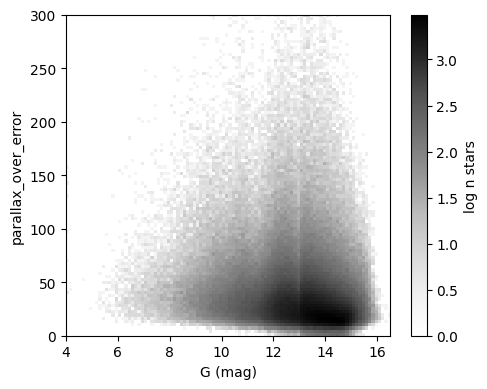

In [20]:
extent = [4,16.5,0,300]
H, xedges, yedges = easy2dhist.hist2d_raw(goodfidelity_badruwe['phot_g_mean_mag'],goodfidelity_badruwe['parallax_over_error'], bins=(100, 100),xrange=(extent[0],extent[1]),yrange=(extent[2],extent[3]))

plt.figure(figsize=(5,4))
plt.imshow(np.log10(H.T), extent=extent,aspect='auto',origin='lower',cmap=cm.Greys)
plt.xlabel('G (mag)')
plt.ylabel('parallax_over_error')
plt.colorbar(label='log n stars')
plt.tight_layout()

This feels like a puzzle!